In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from hodalpt.sims import alpt as CS
from hodalpt.sims import quijote as Q
from hodalpt import stats

In [2]:
ic_path = '/Users/mcc3842/CosmicSim2025/data/quijote/latin_hypercube_HR/100/ICs/'
outdir = '/Users/mcc3842/CosmicSim2025/data/quijote/latin_hypercube_HR/100/alpt/'

## base ALPT HOD vs HOD + subgrid comparison

In [3]:
theta_gal = {
    'alpha': 1.9230, 
    'beta': 2.0253, 
    'dth': -0.7889, 
    'rhoeps': 14.6874, 
    'eps': 0.5616, 
    'nmean': 3.3e-4, 
    'rhoepsprime': 0., 
    'epsprime': 0.}
theta_rsd = {
    'bv': 0.7289, 
    'bb': 1.1652,
    'betarsd': 1.3136, 
    'gamma': 0.4944}

# without subgrid 
xyz_g0 = CS.CSbox_galaxy(theta_gal, theta_rsd, outdir, bias_model='local', subgrid=False, silent=True)
spec = stats.Pk_periodic(xyz_g0.T, Lbox=1000, Ngrid=256, Nmubin=20, fft='pyfftw', silent=True,rsd=2)
bispec = stats.B0_periodic(xyz_g0.T, w=None, Lbox=1000., fft='pyfftw', silent=True)

# xyz_g1 = CS.CSbox_galaxy(theta_gal, theta_rsd, outdir, bias_model='local', subgrid=True, silent=True)
# spec_sg = stats.Pk_periodic(xyz_g1.T, Lbox=1000, Ngrid=256, Nmubin=20, fft='pyfftw', silent=True,rsd=2)
# bispec_sg = stats.B0_periodic(xyz_g1.T, w=None, Lbox=1000., fft='pyfftw', silent=True)



OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


-->Find starting indices ...
-->Start loop over cells of the mesh ...


In [72]:

kmin = 0.008
kmax = 0.8

k = spec['k']
k_mask = (k >= kmin) & (k <= kmax)
k_bins = k[k_mask]
n_k = np.sum(k_mask)
p0k = np.zeros((2, n_k))
p2k = np.zeros((2, n_k))

p0k[0, :] = spec['p0k'][k_mask]
p0k[1, :] = spec_sg['p0k'][k_mask]

p2k[0, :] = spec['p2k'][k_mask]
p2k[1, :] = spec_sg['p2k'][k_mask]



i_k1 = bispec['i_k1'][:]
i_k2 = bispec['i_k2'][:]
i_k3 = bispec['i_k3'][:]
k_fund = 2 * np.pi / 1000.
k1, k2, k3 = i_k1 * k_fund, i_k2 * k_fund, i_k3 * k_fund

klim = (k1 > kmin) & (k2 > kmin) & (k3 > kmin) & (k1 < kmax) & (k2 < kmax) & (k3 < kmax)
n_triangles = np.sum(klim)

b123 = np.zeros((2, n_triangles))
b123[0,:] = bispec['b123'][:][klim]
b123[1,:] = bispec_sg['b123'][:][klim]

q123 = np.zeros((2, n_triangles))
q123[0,:] = bispec['q123'][:][klim]
q123[1,:] = bispec_sg['q123'][:][klim]





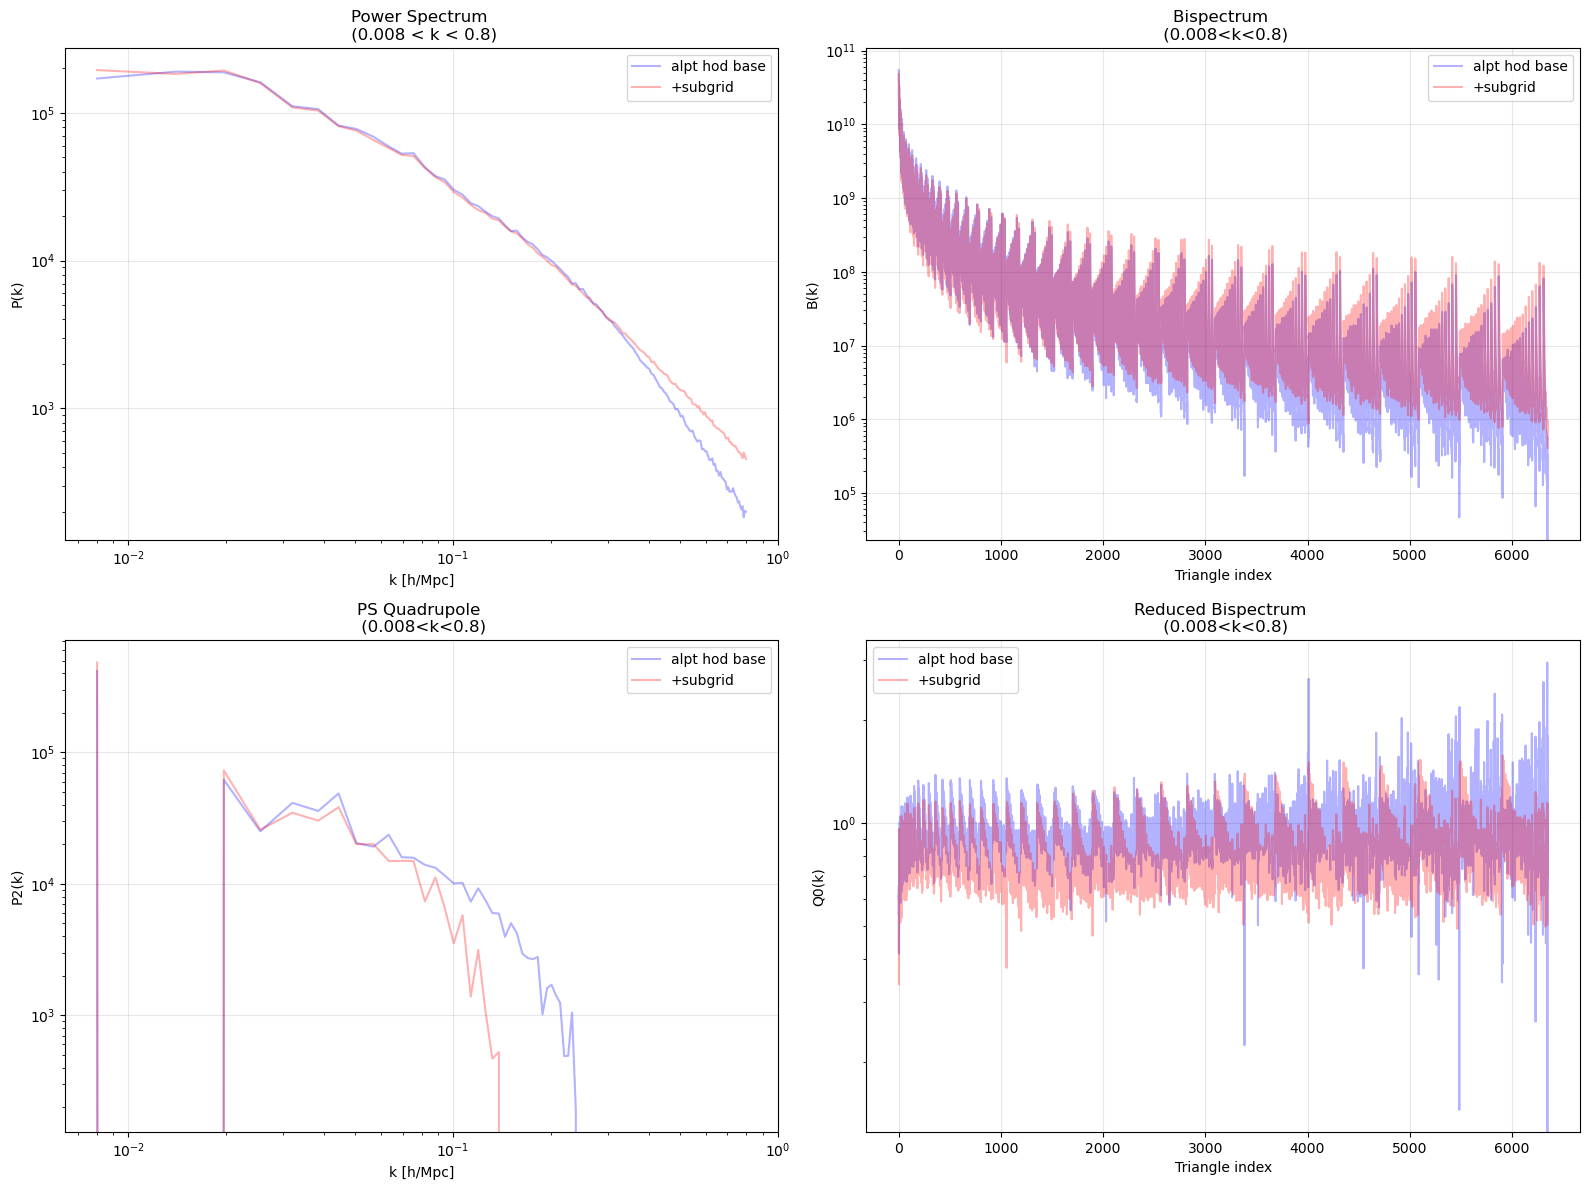

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

k = k_bins
axes[0].loglog(k, p0k[0], 'b-', alpha=0.3, label='alpt hod base')
axes[0].loglog(k, p0k[1], 'r-', alpha=0.3, label='+subgrid')
axes[0].set_xlabel('k [h/Mpc]')
axes[0].set_ylabel('P(k)')
axes[0].set_title(f'Power Spectrum \n ({kmin} < k < {kmax})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(np.sum(klim)), b123[0], 'b-', alpha=0.3, label='alpt hod base')
axes[1].plot(range(np.sum(klim)), b123[1], 'r-', alpha=0.3, label='+subgrid')
axes[1].set_xlabel('Triangle index')
axes[1].set_ylabel('B(k)')
axes[1].set_title(f'Bispectrum \n ({kmin}<k<{kmax})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

axes[2].loglog(k, p2k[0], 'b-', alpha=0.3, label='alpt hod base')
axes[2].loglog(k, p2k[1], 'r-', alpha=0.3, label='+subgrid')
axes[2].set_xlabel('k [h/Mpc]')
axes[2].set_ylabel('P2(k)')
axes[2].set_title(f'PS Quadrupole \n ({kmin}<k<{kmax})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(range(np.sum(klim)), q123[0], 'b-', alpha=0.3, label='alpt hod base')
axes[3].plot(range(np.sum(klim)), q123[1], 'r-', alpha=0.3, label='+subgrid')
axes[3].set_xlabel('Triangle index')
axes[3].set_ylabel('Q0(k)')
axes[3].set_title(f'Reduced Bispectrum \n ({kmin}<k<{kmax})')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
axes[3].set_yscale('log')

plt.tight_layout()

## nonlocal bias comparisons

In [5]:
# alpha, beta, nmean fit by francesco, other pars arbitrary or unused 
alpha = np.array([0.29685723, 1.06796392, 1.99415336, 0.85211754, 0.63162251, 1.61120672, 2.51800086, 2.56070147, 1.20938235, 0.36272172, 1.73030157, 0.85211754, 0.85211754, 0.85211754, 0.85211754, 0.85211754])
beta = np.array([82.91475146 ,68.33632545 ,39.27743698 ,25.15950722 ,87.1500282 ,25.42614578 ,71.29493583 ,77.82969567 ,70.43144589 ,3.71638296 ,71.68769349 ,56.65364231 ,25.15950722,25.15950722,25.15950722,25.15950722])
nmean = np.array([0.00012344299466349185, 3.0023000363144092e-05, 1.0960000054183183e-06, 9.999999717180685e-10, 6.269499863265082e-05, 9.156700252788141e-05, 8.287000127893407e-06, 3.899999967416079e-08, 3.330000026835478e-06, 7.215000096039148e-06, 2.342000016142265e-06, 3.199999909497819e-08, 1.6999999630229468e-08, 5.99999978589949e-08, 1.2000000104706032e-08, 0.0])
theta_gal = {
    'alpha': alpha.reshape((4, 4)),  
    'beta': beta.reshape((4, 4)), 
    'nmean': nmean.reshape((4, 4))
}
theta_rsd = {
    'bv': 0.7289, 
    'bb': 1.1652,
    'betarsd': 1.3136, 
    'gamma': 0.4944}

xyz_g2 = CS.CSbox_galaxy(theta_gal, theta_rsd, outdir, bias_model='nonlocal0', subgrid=False, silent=False)
spec_nlb = stats.Pk_periodic(xyz_g2.T, Lbox=1000, Ngrid=256, Nmubin=20, fft='pyfftw', silent=True,rsd=2)
bispec_nlb = stats.B0_periodic(xyz_g2.T, w=None, Lbox=1000., fft='pyfftw', silent=True)

OM0.313OL0.687G256V1000.0_ALPTrs5.000z0.500.dat
Omega_m 0.313000
reading /Users/mcc3842/CosmicSim2025/data/quijote/latin_hypercube_HR/100/alpt/BOXpos*OM0.313OL0.687G256V1000.0_ALPTrs5.000z0.500.dat
Reading input ...
Getting number counts via parametric bias ...
Number counts diagnostics (min, max, mean):  0.0 8.0 0.029813945293426514
Preparing galaxy positions ...
Sampling galaxy positions ...
-->Find starting indices ...
-->Start loop over cells of the mesh ...
apply RSD ...


In [13]:
# HOD for quijote 
# ics = Q.IC('/Users/mcc3842/CosmicSim2025/data/quijote/latin_hypercube_HR/100')
theta_hod = {
    'logMmin': 13.06,
    'sigma_logM': 0.34,
    'logM0': 13.74,
    'logM1': 14.17,
    'alpha': 0.69,
    'Abias': 0.1, 
    'eta_conc': 1.12,
    'eta_cen': 0.3,
    'eta_sat': 1.26}
hod_quijote = Q.HODgalaxies(theta_hod,'/Users/mcc3842/CosmicSim2025/data/quijote/latin_hypercube_HR/100', z=0.5)
# get redshift-space positions
xyz_q = Q.Box_RSD(hod_quijote, LOS=[0,0,1], Lbox=1000.)
quijote_bispec = stats.B0_periodic(xyz_q.T, w=None, Lbox=1000., fft='pyfftw', silent=True)
b123_quijote = quijote_bispec['b123']
q123_quijote = quijote_bispec['q123']

/Users/mcc3842/CosmicSim2025/hodalpt/src/hodalpt/sims/quijote.py:132: RuntimeWarning: divide by zero encountered in divide
  conc = rstar[:,3] / rstar[:,4]
/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/phase_space_models/analytic_models/satellites/nfw/biased_nfw_phase_space.py:225: UserWarning: You have selected 18 bins to digitize host halo concentration 
and 96 bins to digitize the galaxy bias parameter.
To populate mocks, the BiasedNFWPhaseSpace class builds a lookup table with shape (18, 96, 101),
one entry for every numerical solution to the Jeans equation.
Using this fine of a binning requires a long pre-computation of 174528 integrals
.Make sure you actually need to use so many bins
  warn(lookup_table_performance_warning.format(*args))
/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/factories/hod_model_factory.py:890: UserWarning: The composite model received mu

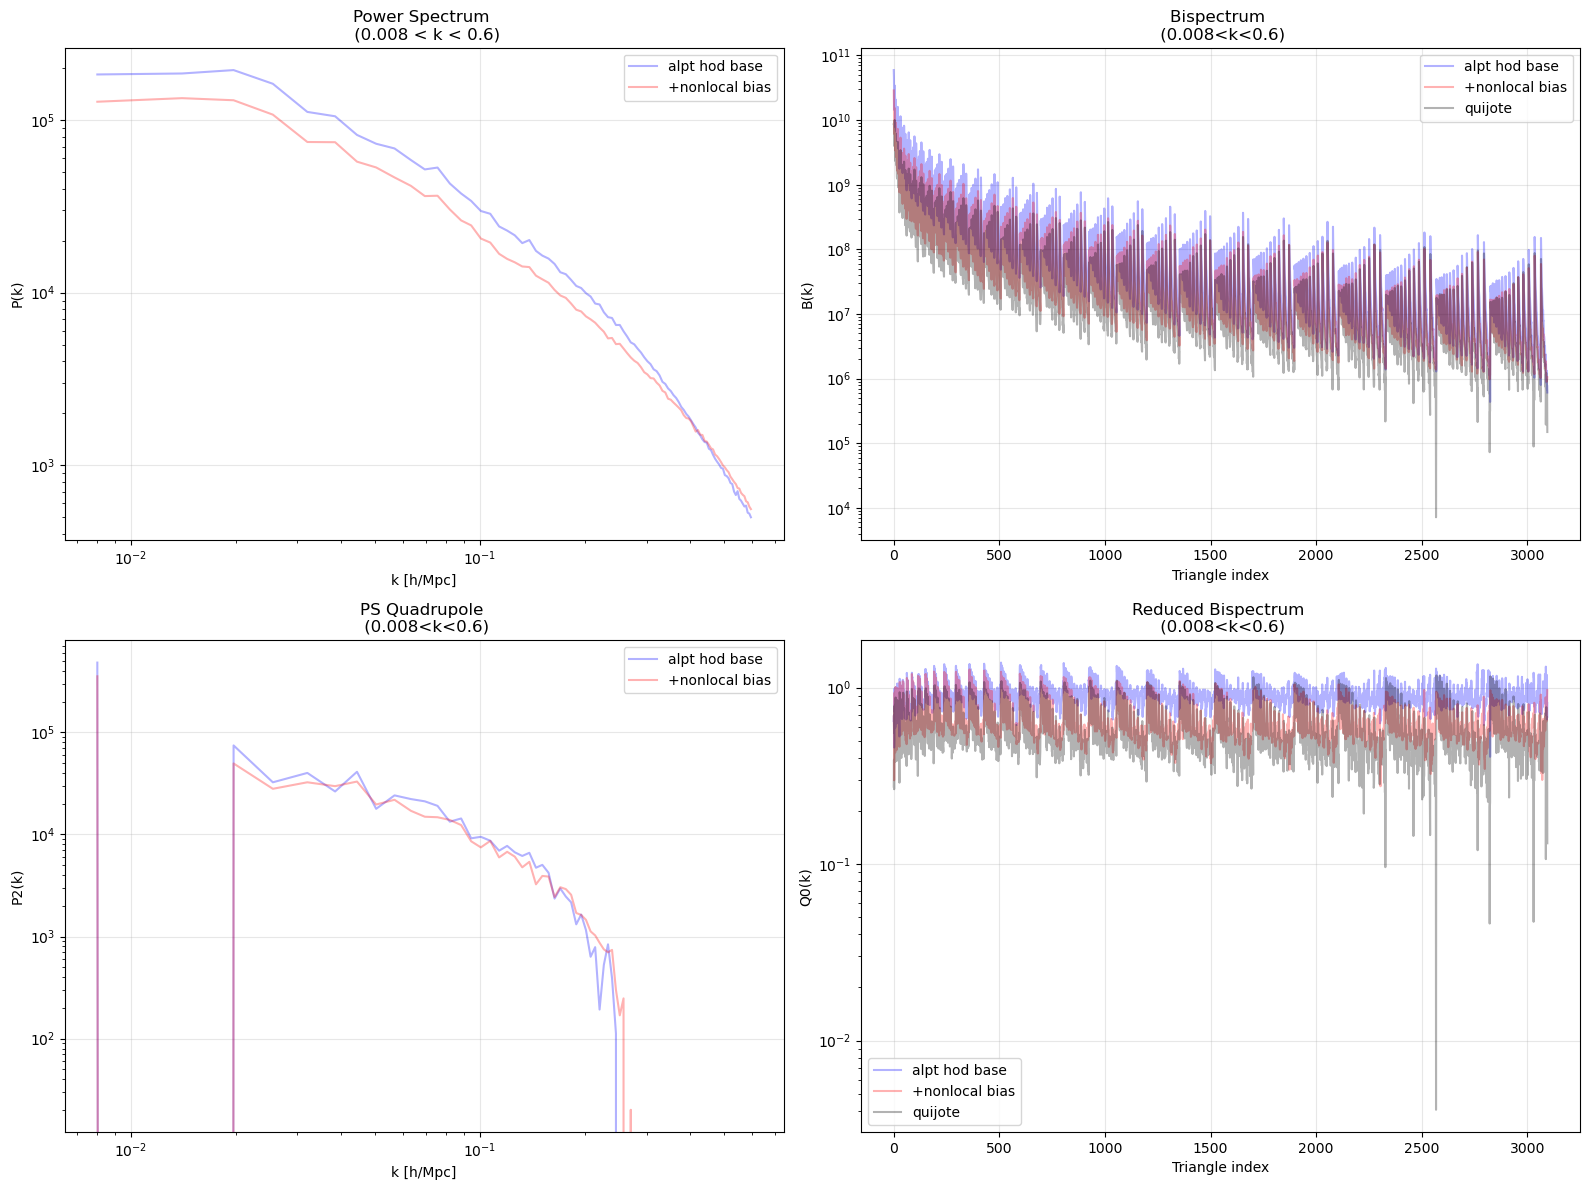

In [19]:

kmin = 0.008
kmax = 0.6

k = spec['k']
k_mask = (k >= kmin) & (k <= kmax)
k_bins = k[k_mask]
n_k = np.sum(k_mask)
p0k = np.zeros((2, n_k))
p2k = np.zeros((2, n_k))

p0k[0, :] = spec['p0k'][k_mask]
p0k[1, :] = spec_nlb['p0k'][k_mask]

p2k[0, :] = spec['p2k'][k_mask]
p2k[1, :] = spec_nlb['p2k'][k_mask]



i_k1 = bispec['i_k1'][:]
i_k2 = bispec['i_k2'][:]
i_k3 = bispec['i_k3'][:]
k_fund = 2 * np.pi / 1000.
k1, k2, k3 = i_k1 * k_fund, i_k2 * k_fund, i_k3 * k_fund

klim = (k1 > kmin) & (k2 > kmin) & (k3 > kmin) & (k1 < kmax) & (k2 < kmax) & (k3 < kmax)
n_triangles = np.sum(klim)

b123 = np.zeros((3, n_triangles))
b123[0,:] = bispec['b123'][:][klim]
b123[1,:] = bispec_nlb['b123'][:][klim]
b123[2,:] = quijote_bispec['b123'][:][klim]

q123 = np.zeros((3, n_triangles))
q123[0,:] = bispec['q123'][:][klim]
q123[1,:] = bispec_nlb['q123'][:][klim]
q123[2,:] = quijote_bispec['q123'][:][klim]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

k = k_bins
axes[0].loglog(k, p0k[0], 'b-', alpha=0.3, label='alpt hod base')
axes[0].loglog(k, p0k[1], 'r-', alpha=0.3, label='+nonlocal bias')
axes[0].set_xlabel('k [h/Mpc]')
axes[0].set_ylabel('P(k)')
axes[0].set_title(f'Power Spectrum \n ({kmin} < k < {kmax})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(np.sum(klim)), b123[0], 'b-', alpha=0.3, label='alpt hod base')
axes[1].plot(range(np.sum(klim)), b123[1], 'r-', alpha=0.3, label='+nonlocal bias')
axes[1].plot(range(np.sum(klim)), b123[2], 'black', alpha=0.3, label='quijote')
axes[1].set_xlabel('Triangle index')
axes[1].set_xlabel('Triangle index')
axes[1].set_ylabel('B(k)')
axes[1].set_title(f'Bispectrum \n ({kmin}<k<{kmax})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

axes[2].loglog(k, p2k[0], 'b-', alpha=0.3, label='alpt hod base')
axes[2].loglog(k, p2k[1], 'r-', alpha=0.3, label='+nonlocal bias')
axes[2].set_xlabel('k [h/Mpc]')
axes[2].set_ylabel('P2(k)')
axes[2].set_title(f'PS Quadrupole \n ({kmin}<k<{kmax})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(range(np.sum(klim)), q123[0], 'b-', alpha=0.3, label='alpt hod base')
axes[3].plot(range(np.sum(klim)), q123[1], 'r-', alpha=0.3, label='+nonlocal bias')
axes[3].plot(range(np.sum(klim)), q123[2], 'black', alpha=0.3, label='quijote')
axes[3].set_xlabel('Triangle index')
axes[3].set_ylabel('Q0(k)')
axes[3].set_title(f'Reduced Bispectrum \n ({kmin}<k<{kmax})')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
axes[3].set_yscale('log')

plt.tight_layout()

In [ ]:
# let's play with param pruning
rng = np.random.default_rng(42)

alpha = np.array([0.29685723, 1.06796392, 1.99415336, 0.85211754, 0.63162251, 1.61120672, 2.51800086, 2.56070147, 1.20938235, 0.36272172, 1.73030157, 0.85211754, 0.85211754, 0.85211754, 0.85211754, 0.85211754])
beta = np.array([82.91475146 ,68.33632545 ,39.27743698 ,25.15950722 ,87.1500282 ,25.42614578 ,71.29493583 ,77.82969567 ,70.43144589 ,3.71638296 ,71.68769349 ,56.65364231 ,25.15950722,25.15950722,25.15950722,25.15950722])
nmean = np.array([0.00012344299466349185, 3.0023000363144092e-05, 1.0960000054183183e-06, 9.999999717180685e-10, 6.269499863265082e-05, 9.156700252788141e-05, 8.287000127893407e-06, 3.899999967416079e-08, 3.330000026835478e-06, 7.215000096039148e-06, 2.342000016142265e-06, 3.199999909497819e-08, 1.6999999630229468e-08, 5.99999978589949e-08, 1.2000000104706032e-08, 0.0])
alpha = alpha.reshape((4,4))
beta = beta.reshape((4,4))
nmean = nmean.reshape((4,4))
k, f, s, v = 0, 1, 2, 3

envs = {
        'k': k,
        'f': f, 
        's': s, 
        'v': v
        }

ienvs = {}
for key_t in envs.keys():
    for key_d in envs.keys():
        ix = (envs[key_t], envs[key_d])
        label = key_t+key_d
        ienvs[label] = ix

# set to 0.0 for priors
print(nmean[v,:])
print(nmean[:, v])

# set to uniform(1e-6, 9e-6)
print(nmean[s,:v])
print(nmean[:v, s])

# set to uniform(1e-5, 1e-4)
print(nmean[f,:s])
print(nmean[:s, f])

# set to uniform(1e-4, 1e-3)
print(nmean[k,k])




[1.69999996e-08 5.99999979e-08 1.20000001e-08 0.00000000e+00]
[9.99999972e-10 3.89999997e-08 3.19999991e-08 0.00000000e+00]
[3.33000003e-06 7.21500010e-06 2.34200002e-06]
[1.09600001e-06 8.28700013e-06 2.34200002e-06]
[6.26949986e-05 9.15670025e-05]
[3.00230004e-05 9.15670025e-05]
0.00012344299466349185
